# Q Learning

### Loading Data From Section 01_data_and_sizing

LOADING KAROUN LOAD DATA
Load matrix shape: (1, 8760)
Load stats — Min: 115.29, Max: 22970.41, Mean: 9726.39
Load flat length: 8760

LOADING PREPARED HOURLY WEATHER DATA
Weather hours: 8760
Date range: 2020-01-01 00:00:00 to 2020-12-31 23:00:00
Columns: ['GHI', 'DNI', 'DHI', 'temp_air', 'relative_humidity', 'pressure', 'wind_speed', 'WindDirection', 'solar_elevation']

ALIGNING LOAD AND WEATHER DATA

Weather hours: 8760
Load hours:    8760
Match:         True

Weather range: 2020-01-01 00:00:00 to 2020-12-31 23:00:00
Load range:    2020-01-01 00:00:00 to 2020-12-31 23:00:00
Indices match: True

Load stats:
  Min:  115.3 kW
  Max:  22970.4 kW
  Mean: 9726.4 kW

GHI stats:
  Min:  0.0 W/m²
  Max:  1094.8 W/m²
  Mean: 259.2 W/m²

✓ Both datasets aligned and ready for PVlib processing!
PV SYSTEM CONFIGURATION

Location: Baalbeck, Lebanon
  Latitude: 34.272946°N
  Longitude: 36.4270535°E
  Altitude: 910 m

PV System:
  Capacity: 1 kW (1 kWp for specific yield)
  Tilt: 30°
  Azimuth: 180° (s

C:\Users\afifb\AppData\Local\Temp\ipykernel_17008\543674702.py:168: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  dc_power_watts = pvlib.pvsystem.pvwatts_dc(



  Target met at: 29,000 kWh
  LPSP: 0.7000 (target: 0.7)
  Charge/discharge rate: 7,250 kW
  TEL at this size: 5,332 kWh

    Battery (kWh)       LPSP       TEL (kWh)
  ------------------------------------------
            1,000     0.7130       1,211,489
            6,000     0.7061         566,894
           11,000     0.7024         221,523
           16,000     0.7009          76,449
           21,000     0.7002          21,818
           26,000     0.7001           8,910
           31,000     0.7000           3,786
           36,000     0.6999           2,429
           41,000     0.6999           1,963
           46,000     0.6998           1,963
           51,000     0.6998           1,963
           56,000     0.6997           1,963
           61,000     0.6997           1,963
           66,000     0.6996           1,963
           71,000     0.6996           1,963
           76,000     0.6995           1,963


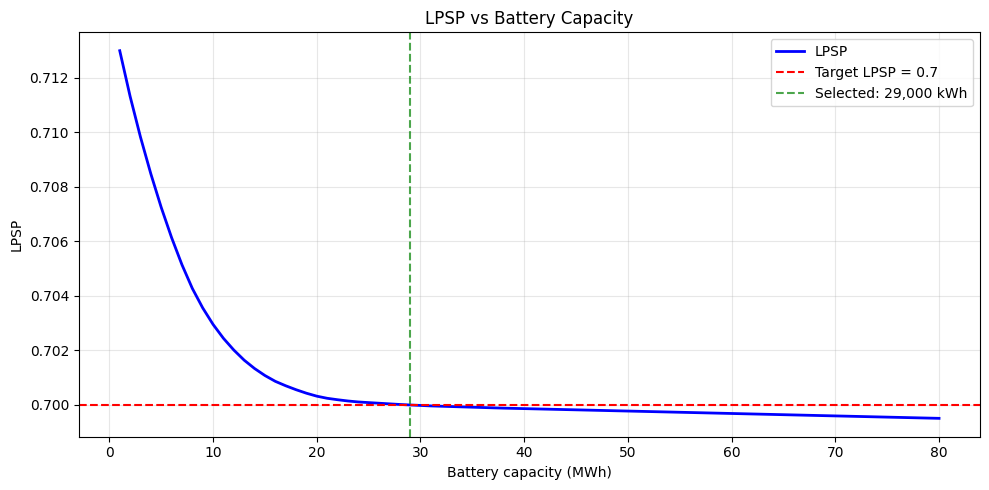

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MICROGRID CONFIGURATION (30% PENETRATION)

  PV Capacity:          12,279 kWp
  Battery Capacity:     29,000 kWh
  Charge Rate:          7,250 kW
  Discharge Rate:       7,250 kW
  Genset Capacity:      25,000 kW
  Battery Efficiency:   0.9487 (√0.9, charge side)
  Init SOC:             1.0
  PV File:              pv_hourly_tier1.npy

  PV array shape:       (8760, 1)
  Load array shape:     (8760, 1)
  PV annual gen:        25,682,847 kWh
  Load annual total:    85,203,148 kWh
  PV NaNs:              0

MICROGRID CREATED
Microgrid([load x 1, renewable x 1, balancing x 2, genset x 1, battery x 1])

Verification:
  Battery SOC after reset: 1.00
  Hour 0  — PV: 30.6 kW, Load: -903.2 kW
  Hour 9  — PV: 12,289.2 kW, Load: -8,691.2 kW
  Hour 12 — PV: 7,476.5 kW, Load: -8,928.7 kW


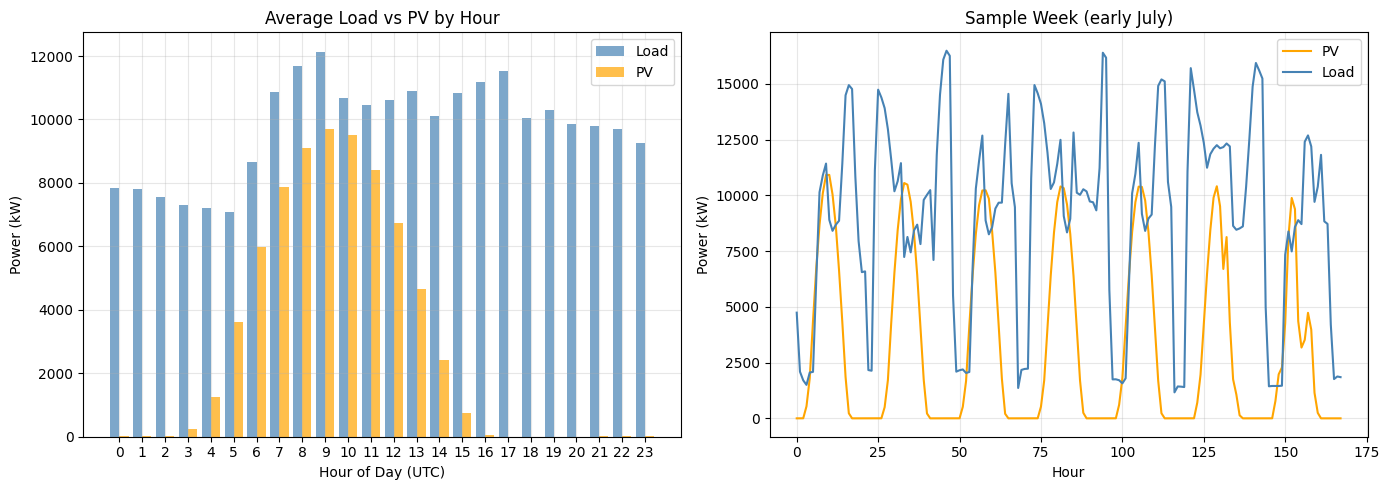


✅ MICROGRID READY


In [1]:
import os
os.chdir(r"C:\Users\afifb\Desktop\IEEE_smartgrid\01_data_and_sizing")
%run ../01_data_and_sizing/01_data_and_sizing.ipynb

In [2]:
import os
os.chdir(r"C:\Users\afifb\Desktop\IEEE_smartgrid\03_reinforcement_learning")

## Wrapper

In [11]:
# ============================================================
# Q-LEARNING GYM ENVIRONMENT v3
# ============================================================
# CHANGES FROM v2:
#   1. Reward function replaced with exact PPO/TD3 reward (reward_scale = 10000)
#   2. Removed the +safe_charge*0.5 shaping term
#   3. Episode length fixed to 48 hours (not 23/47)
#   4. fixed_soc option added to reset() for test-time eval consistency
# Binning, actions, and state space kept identical to v2.
# ============================================================

import numpy as np

class MicrogridQLearningEnv:

    def __init__(self, mg, battery, genset, load_module, pv_module,
                 balancing, converter):

        self.mg = mg
        self.battery = battery
        self.genset = genset
        self.load_module = load_module
        self.pv_module = pv_module
        self.balancing = balancing
        self.converter = converter

        self.episode_length = 48
        self.current_step = 0
        self.day_offset = 0

        self.total_hours = len(load_module.time_series)
        self.total_days = self.total_hours // 24

        # =============================================
        # STATE SPACE BINS (unchanged from v2)
        # =============================================
        self.soc_bins = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.0]
        self.n_soc_bins = 7

        self.net_energy_bins = [-np.inf, -5000, -1000, 0, 2000, np.inf]
        self.n_net_bins = 5

        self.hour_bins = [0, 5, 7, 9, 11, 13, 15, 17, 23]
        self.n_hour_bins = 8

        self.n_states = self.n_soc_bins * self.n_net_bins * self.n_hour_bins

        # =============================================
        # ACTION SPACE (unchanged from v2)
        # =============================================
        self.actions = [
            {'battery_kw':  -500, 'genset_on': False},  # 0
            {'battery_kw': -1000, 'genset_on': False},  # 1
            {'battery_kw': -2000, 'genset_on': False},  # 2
            {'battery_kw': -3500, 'genset_on': False},  # 3
            {'battery_kw':     0, 'genset_on': False},  # 4
            {'battery_kw':  1250, 'genset_on': False},  # 5
            {'battery_kw':  2500, 'genset_on': False},  # 6
            {'battery_kw':  3750, 'genset_on': False},  # 7
            {'battery_kw':  5000, 'genset_on': False},  # 8
            {'battery_kw':     0, 'genset_on': True},   # 9
            {'battery_kw':  1250, 'genset_on': True},   # 10
            {'battery_kw':  2500, 'genset_on': True},   # 11
            {'battery_kw':  3750, 'genset_on': True},   # 12
            {'battery_kw':  5000, 'genset_on': True},   # 13
        ]
        self.n_actions = len(self.actions)

        self.min_soc = 0.20

        # Reward scale — matches PPO/TD3
        self.reward_scale = 10000.0

        # Genset min fraction — needed for AUTO logic
        self.genset_max_kw = genset.running_max_production
        self.genset_min_production = genset.min_production
        self.genset_min_load_fraction = self.genset_min_production / self.genset_max_kw

    # =============================================
    # STATE DISCRETISATION (unchanged from v2)
    # =============================================

    def discretise_soc(self, soc):
        for i in range(len(self.soc_bins) - 1):
            if soc < self.soc_bins[i + 1]:
                return i
        return self.n_soc_bins - 1

    def discretise_net_energy(self, net_energy):
        for i in range(len(self.net_energy_bins) - 1):
            if net_energy < self.net_energy_bins[i + 1]:
                return i
        return self.n_net_bins - 1

    def discretise_hour(self, hour):
        wrapped_hour = hour % 24
        for i in range(len(self.hour_bins) - 1):
            if wrapped_hour < self.hour_bins[i + 1]:
                return i
        return self.n_hour_bins - 1

    def get_state(self, hour):
        soc = self.battery.soc

        ts_index = self.day_offset * 24 + hour
        pv = self.pv_module.time_series[ts_index][0]
        load = abs(self.load_module.time_series[ts_index][0])
        net_energy = pv - load

        soc_bin = self.discretise_soc(soc)
        net_bin = self.discretise_net_energy(net_energy)
        hour_bin = self.discretise_hour(hour)

        return (soc_bin, net_bin, hour_bin)

    # =============================================
    # ACTION EXECUTION — REWARD NOW MATCHES PPO/TD3
    # =============================================

    def execute_action(self, action_index, hour):
        action_def = self.actions[action_index]
        battery_kw = action_def['battery_kw']
        genset_on = action_def['genset_on']

        ts_index = self.day_offset * 24 + hour
        pv = self.pv_module.time_series[ts_index][0]
        load = abs(self.load_module.time_series[ts_index][0])
        delta = pv - load

        # Capacity-aware battery dispatch
        current_soc = self.battery.soc
        battery_capacity = self.battery.max_capacity

        if battery_kw > 0:  # discharge
            usable_energy = (current_soc - self.min_soc) * battery_capacity
            battery_kw = min(
                battery_kw,
                self.converter.max_discharge_kw,
                max(0, usable_energy)
            )
        elif battery_kw < 0:  # charge
            remaining_capacity = (1.0 - current_soc) * battery_capacity
            battery_kw = max(
                battery_kw,
                -self.converter.max_charge_kw,
                -remaining_capacity
            )

        battery_normalised = self.converter.kw_to_normalized(battery_kw)

        # Genset AUTO logic
        genset_kw = 0.0
        if genset_on and delta < 0:
            battery_actual = battery_kw if battery_kw > 0 else 0
            genset_needed = abs(delta) - battery_actual
            if genset_needed > 0:
                genset_level = genset_needed / self.genset_max_kw
                if genset_level < self.genset_min_load_fraction:
                    genset_level = 0.0
                else:
                    genset_level = np.clip(genset_level, self.genset_min_load_fraction, 1.0)
            else:
                genset_level = 0.0
        else:
            genset_level = 0.0

        if genset_level > 0:
            genset_action = np.array([1, genset_level])
            genset_kw = genset_level * self.genset_max_kw
        else:
            genset_action = np.array([0, 0])

        action = {'genset': [genset_action], 'battery': [battery_normalised]}
        obs, pymgrid_reward, done, info = self.mg.run(action)

        loss_load = self.balancing.logger.get('loss_load', [0])[-1]
        overgen = self.balancing.logger.get('overgeneration', [0])[-1]
        soc = self.battery.soc

        # =============================================
        # REWARD FUNCTION — IDENTICAL TO PPO/TD3
        # =============================================
        reward = 0.0
        reward = reward - genset_kw

        if delta > 0:
            surplus = delta
            reward = reward + surplus
            charge_amount = abs(battery_kw) if battery_kw < 0 else 0.0
            captured = min(charge_amount, surplus)
            reward = reward + 2.0 * captured
            if abs(charge_amount - surplus) > 1.0:
                reward = reward - 2.0 * abs(charge_amount - surplus)

        balance_bonus = 5000.0 * max(0.0, 1.0 - abs(delta) / 1000.0)
        reward = reward + balance_bonus

        if delta < 0:
            if battery_kw < 0:
                reward = reward - 5.0 * genset_kw
            if battery_kw > 0:
                deficit = abs(delta)
                displacement_ratio = min(battery_kw, deficit) / deficit
                reward = reward + 5000.0 * displacement_ratio * soc**2
            if battery_kw > 0 and abs(battery_kw) > abs(delta):
                reward = reward - 2.0 * abs(battery_kw - abs(delta))

        if loss_load > 0:
            reward -= 3.0 * abs(loss_load)
        else:
            reward += 1000.0

        reward -= overgen
        reward = reward / self.reward_scale

        return reward, loss_load, overgen, battery_kw, genset_kw

    # =============================================
    # GYM INTERFACE
    # =============================================

    def reset(self, day=None, fixed_soc=None):
        if day is not None:
            self.day_offset = min(day, self.total_days - 3)
        else:
            self.day_offset = np.random.randint(0, self.total_days - 3)

        self.current_step = 0

        self.mg.reset()

        self.battery = self.mg.modules['battery'][0]
        self.genset = self.mg.modules['genset'][0]
        self.load_module = self.mg.modules['load'][0]
        self.pv_module = self.mg.modules['renewable'][0]
        self.balancing = self.mg.modules['balancing'][0]
        self.converter = BatteryActionConverter(self.battery)

        start_hour = self.day_offset * 24
        self.battery._current_step = start_hour
        self.genset._current_step = start_hour
        self.load_module._current_step = start_hour
        self.pv_module._current_step = start_hour
        self.balancing._current_step = start_hour

        if fixed_soc is not None:
            initial_soc = fixed_soc
        else:
            initial_soc = np.random.uniform(0.2, 1.0)
        self.battery._soc = initial_soc
        self.battery._current_charge = initial_soc * self.battery.max_capacity

        # Refresh genset limits
        self.genset_max_kw = self.genset.running_max_production
        self.genset_min_production = self.genset.min_production
        self.genset_min_load_fraction = self.genset_min_production / self.genset_max_kw

        state = self.get_state(self.current_step)
        return state

    def step(self, action_index):
        hour = self.current_step

        reward, loss_load, overgen, batt_kw, gen_kw = self.execute_action(action_index, hour)

        self.current_step += 1
        done = (self.current_step >= self.episode_length)

        if not done:
            next_state = self.get_state(self.current_step)
        else:
            next_state = self.get_state(self.current_step - 1)

        info = {
            'hour': hour,
            'loss_load': loss_load,
            'overgeneration': overgen,
            'soc': self.battery.soc,
            'day': self.day_offset,
            'battery_kw': batt_kw,
            'genset_kw': gen_kw,
        }

        return next_state, reward, done, info


# ============================================================
# CREATE THE ENVIRONMENT
# ============================================================

env = MicrogridQLearningEnv(
    mg=mg,
    battery=battery_module,
    genset=genset_module,
    load_module=load_module,
    pv_module=pv_module,
    balancing=balancing_module,
    converter=converter
)

print("=" * 70)
print("Q-LEARNING ENVIRONMENT v3 — REWARD MATCHES PPO/TD3")
print("=" * 70)
print(f"\n  State space:")
print(f"    SOC bins:        {env.n_soc_bins}")
print(f"    Net Energy bins: {env.n_net_bins}")
print(f"    Hour bins:       {env.n_hour_bins}")
print(f"    Total states:    {env.n_states}")
print(f"\n  Actions:         {env.n_actions}")
print(f"  Q-table size:    {env.n_states * env.n_actions:,} entries")
print(f"  Episode length:  {env.episode_length} steps (48 hours)")
print(f"  Reward:          PPO/TD3 formulation with reward_scale = {env.reward_scale:.0f}")
print(f"\n  Environment ready")

Q-LEARNING ENVIRONMENT v3 — REWARD MATCHES PPO/TD3

  State space:
    SOC bins:        7
    Net Energy bins: 5
    Hour bins:       8
    Total states:    280

  Actions:         14
  Q-table size:    3,920 entries
  Episode length:  48 steps (48 hours)
  Reward:          PPO/TD3 formulation with reward_scale = 10000

  Environment ready


## Testing

In [12]:
import os
import numpy as np
import pandas as pd

# ---- Test pairs (same as TD3/PPO) ----
rl_test_dates = pd.read_csv('rl_test_dates.csv', parse_dates=['date'])['date']
test_days = sorted(rl_test_dates.dt.dayofyear.values - 1)
test_days = [d if d < 59 else d - 1 for d in test_days]

test_pair_starts = []
for i in range(0, len(test_days) - 1, 2):
    if test_days[i + 1] - test_days[i] == 1:
        test_pair_starts.append(test_days[i])

print(f"Test pairs: {len(test_pair_starts)}")

# ---- Environment (v3 wrapper, 48 steps by default) ----
env_ql = MicrogridQLearningEnv(
    mg=mg, battery=battery_module, genset=genset_module,
    load_module=load_module, pv_module=pv_module,
    balancing=balancing_module, converter=converter
)

# ---- Load the Q-table ----
folder = os.path.join('Models', 'QLearning_tier1')
Q_table = np.load(os.path.join(folder, 'QLearning_tier1_final.npy'))
print(f"Q-table shape: {Q_table.shape}")

# ---- Greedy evaluation (no mask, fixed SOC = 1.0) ----
total_ll = 0
for td in test_pair_starts:
    state = env_ql.reset(day=td, fixed_soc=1.0)
    done = False
    while not done:
        action = int(np.argmax(Q_table[state]))
        state, _, done, info = env_ql.step(action)
        total_ll += info['loss_load']

print(f"\n  Total loss load: {total_ll:,.0f} kWh")
print(f"  Avg loss load:   {total_ll/len(test_pair_starts):,.0f} kWh")

Test pairs: 36
Q-table shape: (7, 5, 8, 14)

  Total loss load: 2,900,740 kWh
  Avg loss load:   80,576 kWh
